# 🏆 Sports Slot Price Predictor
### ML Analysis Notebook
End-to-end pipeline: EDA → Preprocessing → Model Training → Evaluation → Export


## Step 1 — Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("All libraries imported ✅")

All libraries imported ✅


## Step 2 — Load Dataset

In [2]:
df = pd.read_csv("bookings_dataset.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 10)


,Sport,Booking_Date,Day_of_Week,Is_Weekend,Start_Hour,Duration_Hours,Number_of_Players,Court_Type,Equipment_Rental,Booking_Price
0,Basketball,2026-07-09,Thursday,0,6,3,6,Indoor,Yes,2466.38
1,Pickleball,2026-07-08,Wednesday,0,8,3,3,Indoor,Yes,1417.15
2,Cricket,2026-07-22,Wednesday,0,13,3,15,Indoor,Yes,4607.35
3,Basketball,2026-09-16,Wednesday,0,19,1,7,Outdoor,Yes,1115.94
4,Pickleball,2026-09-22,Tuesday,0,19,2,3,Indoor,Yes,1120.43


## Step 3 — Exploratory Data Analysis (EDA)

In [3]:
# Basic info
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Sport                    str
Booking_Date             str
Day_of_Week              str
Is_Weekend             int64
Start_Hour             int64
Duration_Hours         int64
Number_of_Players      int64
Court_Type               str
Equipment_Rental         str
Booking_Price        float64
dtype: object

Missing values:
Sport                0
Booking_Date         0
Day_of_Week          0
Is_Weekend           0
Start_Hour           0
Duration_Hours       0
Number_of_Players    0
Court_Type           0
Equipment_Rental     0
Booking_Price        0
dtype: int64


In [4]:
# Price distribution
df["Booking_Price"].describe().round(2)

count    1000.00
mean     1956.97
std      1183.71
min       363.64
25%      1040.04
50%      1633.20
75%      2670.08
max      6228.79
Name: Booking_Price, dtype: float64

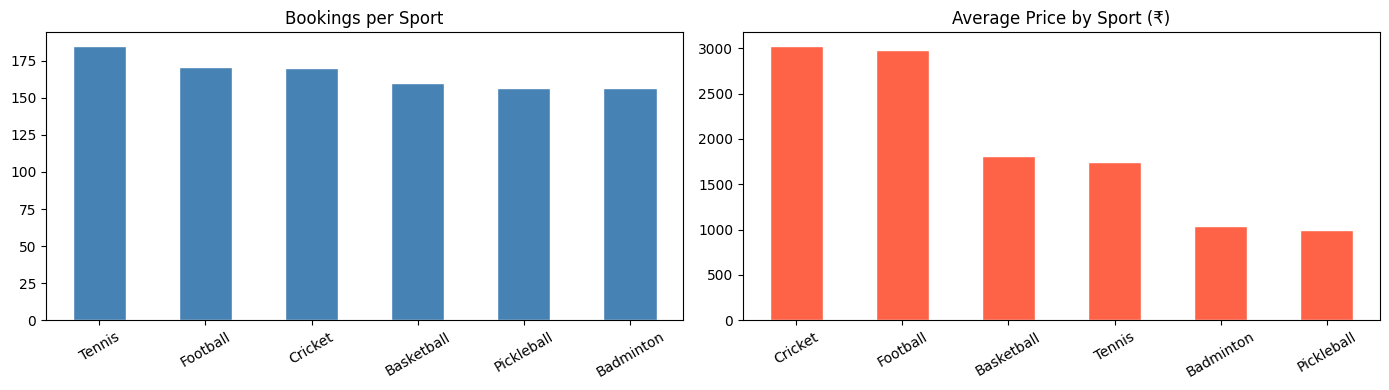

In [5]:
# Bookings per sport
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["Sport"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Bookings per Sport")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=30)

df.groupby("Sport")["Booking_Price"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Average Price by Sport (₹)")
axes[1].set_xlabel("")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Weekday avg ₹: 1803.03
Weekend avg ₹: 2341.28


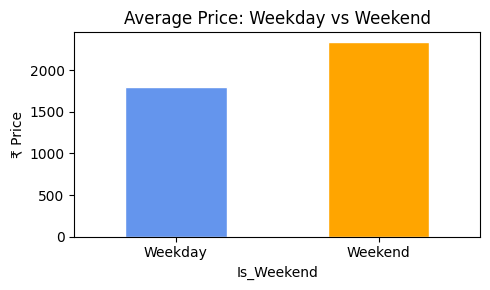

In [6]:
# Weekend vs Weekday pricing
weekend_avg = df.groupby("Is_Weekend")["Booking_Price"].mean().round(2)
print("Weekday avg ₹:", weekend_avg[0])
print("Weekend avg ₹:", weekend_avg[1])

df.groupby("Is_Weekend")["Booking_Price"].mean().plot(
    kind="bar", color=["cornflowerblue","orange"], edgecolor="white", figsize=(5,3))
plt.xticks([0,1], ["Weekday","Weekend"], rotation=0)
plt.title("Average Price: Weekday vs Weekend")
plt.ylabel("₹ Price")
plt.tight_layout()
plt.show()

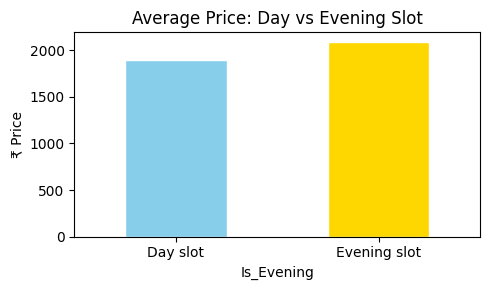

In [7]:
# Evening premium (18:00+)
df["Is_Evening"] = (df["Start_Hour"] >= 18).astype(int)
df.groupby("Is_Evening")["Booking_Price"].mean().round(2).rename({0:"Day slot",1:"Evening slot"}).plot(
    kind="bar", color=["skyblue","gold"], edgecolor="white", figsize=(5,3))
plt.xticks(rotation=0)
plt.title("Average Price: Day vs Evening Slot")
plt.ylabel("₹ Price")
plt.tight_layout()
plt.show()
df = df.drop(columns=["Is_Evening"])   # clean up helper column

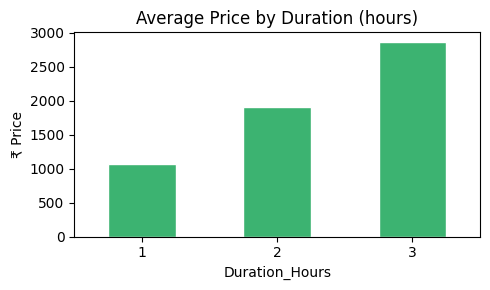

In [8]:
# Price vs Duration
df.groupby("Duration_Hours")["Booking_Price"].mean().round(2).plot(
    kind="bar", color="mediumseagreen", edgecolor="white", figsize=(5,3))
plt.xticks(rotation=0)
plt.title("Average Price by Duration (hours)")
plt.ylabel("₹ Price")
plt.tight_layout()
plt.show()

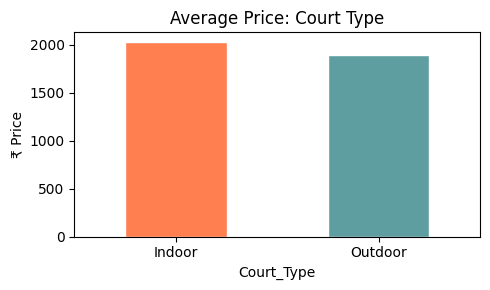

In [9]:
# Indoor vs Outdoor
df.groupby("Court_Type")["Booking_Price"].mean().round(2).plot(
    kind="bar", color=["coral","cadetblue"], edgecolor="white", figsize=(5,3))
plt.xticks(rotation=0)
plt.title("Average Price: Court Type")
plt.ylabel("₹ Price")
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

In [10]:
# Drop Booking_Date — already captured by Day_of_Week and Is_Weekend
df_clean = df.drop(columns=["Booking_Date"])

CATEGORICAL_COLS = ["Sport", "Day_of_Week", "Court_Type", "Equipment_Rental"]
FEATURE_COLS = [
    "Sport", "Day_of_Week", "Court_Type", "Equipment_Rental",
    "Is_Weekend", "Start_Hour", "Duration_Hours", "Number_of_Players"
]
TARGET_COL = "Booking_Price"

encoders = {}
df_enc = df_clean.copy()

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    encoders[col] = le
    print(f"{col}: {list(le.classes_)}")

Sport: ['Badminton', 'Basketball', 'Cricket', 'Football', 'Pickleball', 'Tennis']
Day_of_Week: ['Friday', 'Monday', 'Saturday', 'Sunday', 'Thursday', 'Tuesday', 'Wednesday']
Court_Type: ['Indoor', 'Outdoor']
Equipment_Rental: ['No', 'Yes']


In [11]:
X = df_enc[FEATURE_COLS]
y = df_enc[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
X.head()

Train size: (800, 8)
Test size:  (200, 8)


,Sport,Day_of_Week,Court_Type,Equipment_Rental,Is_Weekend,Start_Hour,Duration_Hours,Number_of_Players
0,1,4,0,1,0,6,3,6
1,4,6,0,1,0,8,3,3
2,2,6,0,1,0,13,3,15
3,1,6,1,1,0,19,1,7
4,4,5,0,1,0,19,2,3


## Step 5 — Train Models

In [12]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)
lr_r2   = r2_score(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)

print(f"Linear Regression → R²: {lr_r2:.4f}  RMSE: {lr_rmse:.2f}  MAE: {lr_mae:.2f}")

Linear Regression → R²: 0.7667  RMSE: 583.09  MAE: 441.09


In [13]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_r2   = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)

print(f"Random Forest     → R²: {rf_r2:.4f}  RMSE: {rf_rmse:.2f}  MAE: {rf_mae:.2f}")

Random Forest     → R²: 0.9783  RMSE: 177.73  MAE: 129.08


## Step 6 — Compare Models

In [14]:
metrics_df = pd.DataFrame({
    "Model":  ["Linear Regression", "Random Forest"],
    "R²":     [round(lr_r2,4),  round(rf_r2,4)],
    "RMSE":   [round(lr_rmse,2),round(rf_rmse,2)],
    "MAE":    [round(lr_mae,2), round(rf_mae,2)],
})
print(metrics_df.to_string(index=False))

            Model     R²   RMSE    MAE
Linear Regression 0.7667 583.09 441.09
    Random Forest 0.9783 177.73 129.08


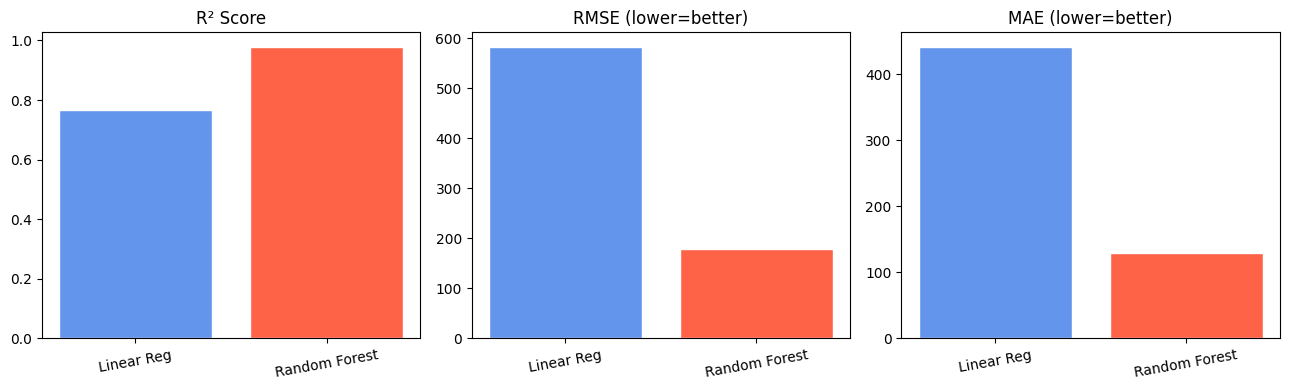

In [15]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["cornflowerblue", "tomato"]
labels = ["Linear Reg", "Random Forest"]

for ax, metric, vals in zip(axes,
    ["R² Score", "RMSE (lower=better)", "MAE (lower=better)"],
    [[lr_r2, rf_r2], [lr_rmse, rf_rmse], [lr_mae, rf_mae]]):
    ax.bar(labels, vals, color=colors, edgecolor="white")
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

## Step 7 — Pick Best Model & Visualise Predictions

In [16]:
if rf_r2 >= lr_r2:
    best_model, best_name, best_preds = rf_model, "Random Forest Regressor", rf_preds
else:
    best_model, best_name, best_preds = lr_model, "Linear Regression", lr_preds

print(f"✅ Best model: {best_name}")

✅ Best model: Random Forest Regressor


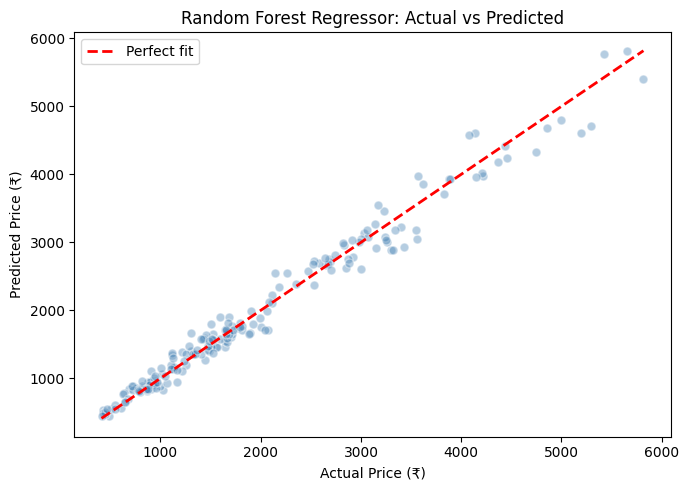

In [17]:
# Actual vs Predicted scatter
plt.figure(figsize=(7,5))
plt.scatter(y_test, best_preds, alpha=0.4, color="steelblue", edgecolors="white", s=40)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect fit")
plt.xlabel("Actual Price (₹)")
plt.ylabel("Predicted Price (₹)")
plt.title(f"{best_name}: Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

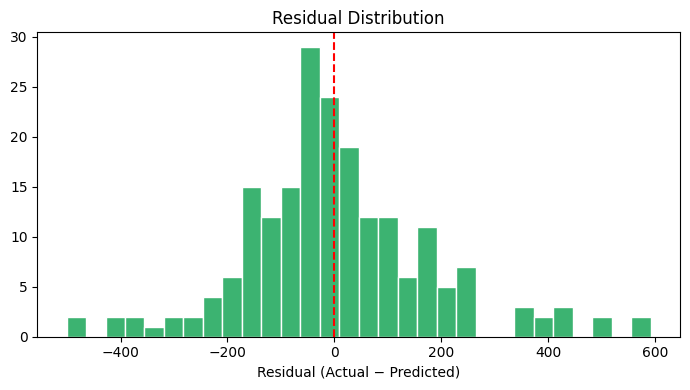

Mean residual: 2.52


In [18]:
# Residual distribution
residuals = y_test.values - best_preds
plt.figure(figsize=(7,4))
plt.hist(residuals, bins=30, color="mediumseagreen", edgecolor="white")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual − Predicted)")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()
print(f"Mean residual: {residuals.mean():.2f}")

## Step 8 — Feature Importance (Random Forest)

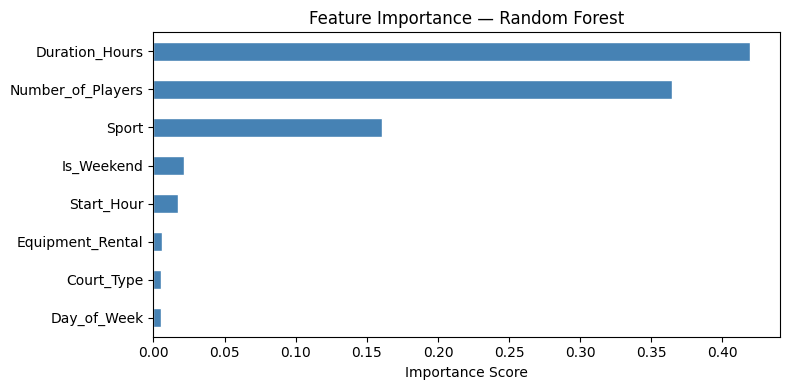

Duration_Hours       0.419496
Number_of_Players    0.364696
Sport                0.160637
Is_Weekend           0.021319
Start_Hour           0.017422
Equipment_Rental     0.005800
Court_Type           0.005626
Day_of_Week          0.005004
dtype: float64


In [19]:
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values()
importances.plot(kind="barh", color="steelblue", edgecolor="white", figsize=(8,4))
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()
print(importances.sort_values(ascending=False))

## Step 9 — Save Model & Encoders

In [20]:
with open("model.pkl", "wb") as f:
    pickle.dump({
        "model":         best_model,
        "model_name":    best_name,
        "feature_order": FEATURE_COLS,
    }, f)

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("✅ model.pkl and encoder.pkl saved — ready for app.py")

✅ model.pkl and encoder.pkl saved — ready for app.py


## Step 10 — Quick Prediction Test

In [21]:
def predict_price(sport, day_of_week, is_weekend, start_hour,
                  duration, num_players, court_type, equipment):
    row = {
        "Sport":             encoders["Sport"].transform([sport])[0],
        "Day_of_Week":       encoders["Day_of_Week"].transform([day_of_week])[0],
        "Court_Type":        encoders["Court_Type"].transform([court_type])[0],
        "Equipment_Rental":  encoders["Equipment_Rental"].transform([equipment])[0],
        "Is_Weekend":        is_weekend,
        "Start_Hour":        start_hour,
        "Duration_Hours":    duration,
        "Number_of_Players": num_players,
    }
    X_in = pd.DataFrame([row])[FEATURE_COLS]
    return best_model.predict(X_in)[0]

# Weekend evening Cricket — should be expensive
p1 = predict_price("Cricket", "Saturday", 1, 19, 3, 11, "Indoor", "Yes")
print(f"Weekend evening Cricket (Indoor, 3h, equip): ₹{p1:,.2f}")

# Weekday morning Badminton — should be cheap
p2 = predict_price("Badminton", "Monday", 0, 8, 1, 2, "Outdoor", "No")
print(f"Weekday morning Badminton (Outdoor, 1h, no equip): ₹{p2:,.2f}")

Weekend evening Cricket (Indoor, 3h, equip): ₹5,894.65
Weekday morning Badminton (Outdoor, 1h, no equip): ₹397.52
